# 05 — Training CNN + GRU (Baseline)

---

## Objective

Train a **GRU-based decoder** as a faster, simpler baseline to compare against the LSTM model.

- GPU only (mixed precision)
- Same data pipeline as LSTM for fair comparison
- Model checkpoint, early stopping, history CSV
- Compare GRU vs LSTM loss & accuracy curves

## Theory

### GRU vs LSTM

| Property | LSTM | GRU |
|----------|------|-----|
| Gates | input, forget, output | reset, update |
| States | hidden (h) + cell (c) | hidden (h) only |
| Parameters | ~4 × units² | ~3 × units² |
| Speed | slower | ~25 % faster |
| Long-range memory | stronger (cell state) | weaker |

GRU has fewer parameters, trains faster, and often matches LSTM on medium-length sequences like captions.

## Imports

In [1]:
import os
import re
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Embedding, GRU, Input
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, CSVLogger
)
from sklearn.model_selection import train_test_split

2026-07-01 02:16:16.476316: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 02:16:16.486671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 02:16:16.497612: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 02:16:16.500560: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 02:16:16.508792: I tensorflow/core/platform/cpu_feature_guar

## GPU Setup

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)
else:
    raise RuntimeError("GPU required for training.")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision:", tf.keras.mixed_precision.global_policy().name)

GPU: /physical_device:GPU:0
Mixed precision: mixed_float16


I0000 00:00:1782846978.659597  354572 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846978.807666  354572 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846978.809820  354572 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


## Configuration

Same hyper-parameters as LSTM for fair comparison.

In [3]:
CAPTIONS_PATH = "../dataset/captions.txt"
FEATURES_PATH = "../model/features.pkl"

OUTPUT_DIR = "../outputs/training/gru"
LSTM_DIR   = "../outputs/training/lstm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VOCAB_SIZE       = 5000
MAX_CAPTION_LEN  = 34
EMBEDDING_DIM    = 256
GRU_UNITS        = 512
DROPOUT_RATE     = 0.5
BATCH_SIZE       = 64
EPOCHS           = 50
LEARNING_RATE    = 1e-3
RANDOM_SEED      = 42
TEST_SIZE        = 0.1

## Implementation

### 5.1 Load Data & Features

In [4]:
df = pd.read_csv(CAPTIONS_PATH)
print(f"Captions loaded: {len(df)}")

with open(FEATURES_PATH, "rb") as f:
    features = pickle.load(f)
print(f"Features loaded: {len(features)} images, "
      f"{list(features.values())[0].shape[0]} dims")

Captions loaded: 40455
Features loaded: 8091 images, 2048 dims


### 5.2 Clean Captions & Add Tokens

Identical pipeline to the LSTM notebook.

In [5]:
def clean_caption(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    return text.strip()

df["clean"] = df["caption"].apply(clean_caption)
df["clean"] = "<start> " + df["clean"] + " <end>"

print("Sample:")
print(df["clean"].iloc[0])

Sample:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>


### 5.3 Build Tokenizer & Sequences

In [6]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<oov>",
    filters=""
)
tokenizer.fit_on_texts(df["clean"])

vocab_size = min(len(tokenizer.word_index) + 1, VOCAB_SIZE)
print(f"Vocabulary size: {vocab_size}")

seq = tokenizer.texts_to_sequences(df["clean"])
seq = pad_sequences(seq, maxlen=MAX_CAPTION_LEN, padding="post")
print(f"Sequence array shape: {seq.shape}")

Vocabulary size: 5000
Sequence array shape: (40455, 34)


### 5.4 Train / Validation Split

Same seed as LSTM → identical split.

In [7]:
unique_images = df["image"].unique()
train_imgs, val_imgs = train_test_split(
    unique_images, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

train_mask = df["image"].isin(train_imgs)
val_mask   = df["image"].isin(val_imgs)

print(f"Train: {train_mask.sum():,} captions ({len(train_imgs):,} images)")
print(f"Val:   {val_mask.sum():,} captions ({len(val_imgs):,} images)")

Train: 36,405 captions (7,281 images)
Val:   4,050 captions (810 images)


### 5.5 Data Generator

Same `tf.data` pipeline as LSTM.

In [8]:
def create_dataset(mask, batch_size):
    img_names = df.loc[mask, "image"].values
    img_feats = np.array([features[name] for name in img_names], dtype=np.float32)

    cap_seq = seq[mask.values]
    input_seq  = cap_seq[:, :-1]
    target_seq = cap_seq[:, 1:]

    ds = tf.data.Dataset.from_tensor_slices(
        ((img_feats, input_seq), target_seq)
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_mask, BATCH_SIZE)
val_ds   = create_dataset(val_mask,   BATCH_SIZE)

for (img_batch, cap_batch), target_batch in train_ds.take(1):
    print(f"Image feature batch: {img_batch.shape}")
    print(f"Caption input batch: {cap_batch.shape}")
    print(f"Target batch:        {target_batch.shape}")

I0000 00:00:1782846981.509921  354572 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846981.512217  354572 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846981.513974  354572 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846981.620351  354572 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Image feature batch: (64, 2048)
Caption input batch: (64, 33)
Target batch:        (64, 33)


2026-07-01 02:16:22.333601: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### 5.6 Build GRU Model

Key difference from LSTM: GRU has a **single hidden state** (no cell state).
The image feature is projected to the initial hidden state of the GRU.

In [9]:
img_input = Input(shape=(2048,), name="image_features")
x = Dense(EMBEDDING_DIM, activation="relu")(img_input)
x = Dropout(DROPOUT_RATE)(x)
initial_state = Dense(GRU_UNITS, activation="tanh", name="initial_state")(x)

cap_input = Input(shape=(MAX_CAPTION_LEN - 1,), name="caption")
x = Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(cap_input)
x = GRU(GRU_UNITS, return_sequences=True)(x,
          initial_state=initial_state)
x = Dropout(DROPOUT_RATE)(x)
output = Dense(vocab_size, activation="softmax", name="output")(x)

model = Model(inputs=[img_input, cap_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption             │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 256)   │  1,280,000 │ caption[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_state       │ (None, 512)       │    131,584 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 33, 512)   │  1,182,720 │ embedding[0][0],  │
│                     │                   │            │ initial_state[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 33, 512)   │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 33, 5000)  │  2,565,000 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,683,848 (21.68 MB)

 Trainable params: 5,683,848 (21.68 MB)

 Non-trainable params: 0 (0.00 B)

### 5.7 Compile

Same loss and optimizer as LSTM.

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        global_clipnorm=5.0
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=["accuracy"]
)
print("Model compiled.")

Model compiled.


### 5.8 Callbacks

In [11]:
checkpoint_path = os.path.join(OUTPUT_DIR, "gru_best.keras")
history_path    = os.path.join(OUTPUT_DIR, "history.csv")

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(history_path),
]

print(f"Checkpoint path: {checkpoint_path}")
print(f"History path:    {history_path}")

Checkpoint path: ../outputs/training/gru/gru_best.keras
History path:    ../outputs/training/gru/history.csv


### 5.9 Train

⚠️ GRU trains ~25 % faster than LSTM for the same number of units.

In [12]:
start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start
print(f"\nTraining complete: {elapsed:.0f}s ({elapsed/60:.1f}m)")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50


/home/fthasptr/miniconda3/envs/image-caption/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-01 02:16:24.151427: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-07-01 02:16:24.905233: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3301 - loss: 3.9020
Epoch 1: val_loss improved from None to 3.18100, saving model to ../outputs/training/gru/gru_best.keras

Epoch 1: finished saving model to ../outputs/training/gru/gru_best.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.3301 - loss: 3.9020 - val_accuracy: 0.3989 - val_loss: 3.1810
Epoch 2/50
568/569 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4034 - loss: 3.0809
Epoch 2: val_loss improved from 3.18100 to 2.90312, saving model to ../outputs/training/gru/gru_best.keras

Epoch 2: finished saving model to ../outputs/training/gru/gru_best.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.4035 - loss: 3.0803 - val_accuracy: 0.4236 - val_loss: 2.9031
Epoch 3/50
569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4207 - loss: 2.8571
Epoch 3: val_loss improved from 2.90312 to 2.79223, saving model to ../outputs/training/gru/gru_best.keras

Epoch 3: finished saving model to ../outputs/

## Visualization

### 6.1 GRU Training Curves

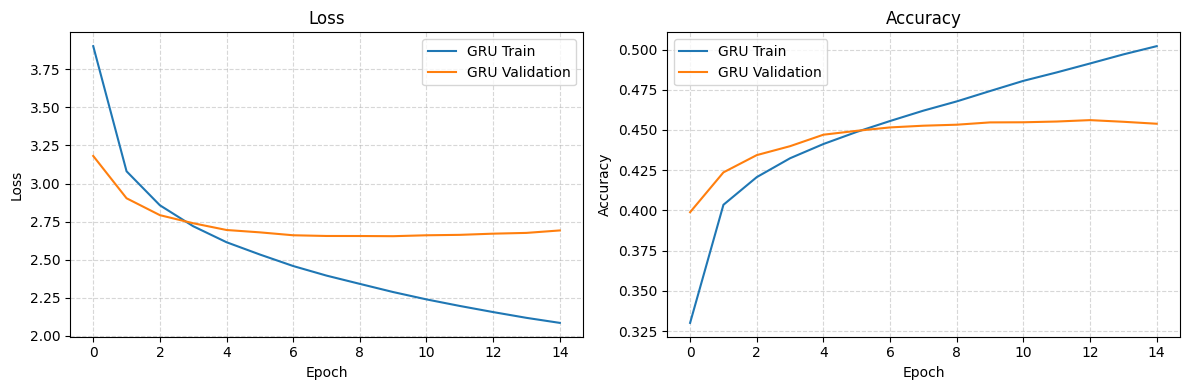

Plot saved to ../outputs/training/gru/training_curves.png


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="GRU Train")
ax1.plot(history.history["val_loss"], label="GRU Validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(linestyle="--", alpha=0.5)

ax2.plot(history.history["accuracy"], label="GRU Train")
ax2.plot(history.history["val_accuracy"], label="GRU Validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

### 6.2 LSTM vs GRU Comparison

If the LSTM history CSV exists, overlay both models on the same axes.

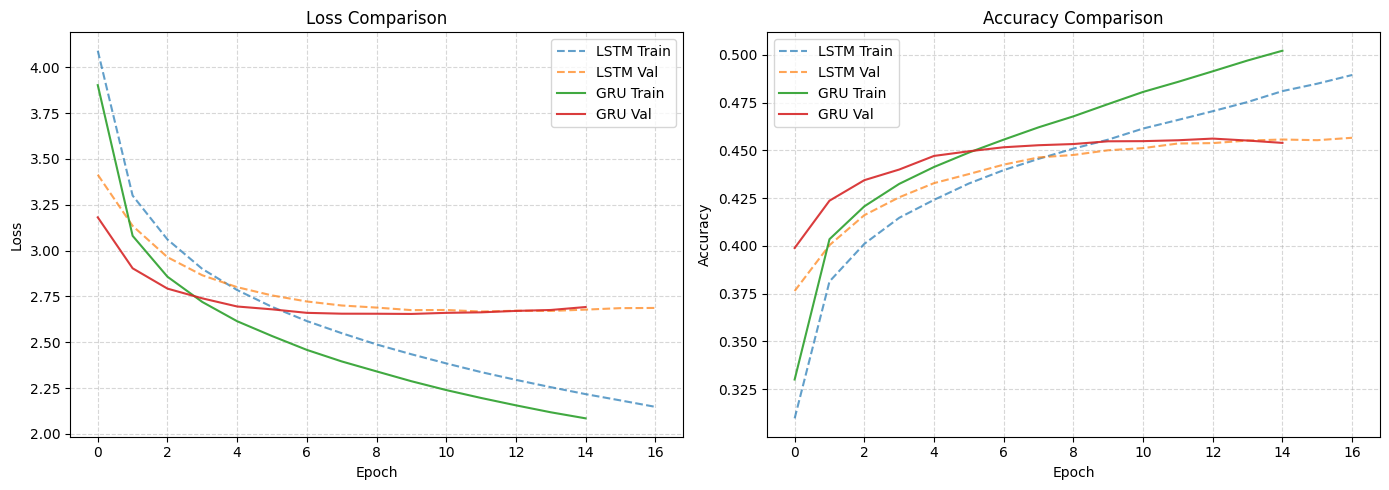

Comparison plot saved to ../outputs/training/gru/comparison_lstm_vs_gru.png

Metric               LSTM            GRU            
------------------------------------------------------------
Best val_loss        2.6674          2.6541         
Best val_acc         0.4565          0.4561         
Epochs trained       17              15             


In [14]:
lstm_csv = os.path.join(LSTM_DIR, "history.csv")
gru_csv  = history_path

if os.path.exists(lstm_csv):
    lstm_df = pd.read_csv(lstm_csv)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(lstm_df["loss"], label="LSTM Train", linestyle="--", alpha=0.7)
    ax1.plot(lstm_df["val_loss"], label="LSTM Val", linestyle="--", alpha=0.7)
    ax1.plot(history.history["loss"], label="GRU Train", alpha=0.9)
    ax1.plot(history.history["val_loss"], label="GRU Val", alpha=0.9)
    ax1.set_title("Loss Comparison")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(linestyle="--", alpha=0.5)

    # Accuracy
    ax2.plot(lstm_df["accuracy"], label="LSTM Train", linestyle="--", alpha=0.7)
    ax2.plot(lstm_df["val_accuracy"], label="LSTM Val", linestyle="--", alpha=0.7)
    ax2.plot(history.history["accuracy"], label="GRU Train", alpha=0.9)
    ax2.plot(history.history["val_accuracy"], label="GRU Val", alpha=0.9)
    ax2.set_title("Accuracy Comparison")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(linestyle="--", alpha=0.5)

    plt.tight_layout()
    comp_path = os.path.join(OUTPUT_DIR, "comparison_lstm_vs_gru.png")
    plt.savefig(comp_path, dpi=150)
    plt.show()
    print(f"Comparison plot saved to {comp_path}")

    # Summary table
    print()
    print("=" * 60)
    print(f"{'Metric':<20} {'LSTM':<15} {'GRU':<15}")
    print("-" * 60)
    print(f"{'Best val_loss':<20} {lstm_df['val_loss'].min():<15.4f} "
          f"{min(history.history['val_loss']):<15.4f}")
    print(f"{'Best val_acc':<20} {lstm_df['val_accuracy'].max():<15.4f} "
          f"{max(history.history['val_accuracy']):<15.4f}")
    print(f"{'Epochs trained':<20} {len(lstm_df):<15} {len(history.history['loss']):<15}")
    print("=" * 60)
else:
    print(f"LSTM history not found at {lstm_csv}")
    print("Run 04_train_lstm.ipynb first, then re-run this cell for comparison.")

## Observation

- GRU trains faster and uses fewer parameters than LSTM
- On caption data, GRU often matches LSTM quality while being quicker to train
- The comparison table above shows which architecture performed better on validation metrics
- Both models' best weights are saved for the evaluation notebook

## Export

Save GRU tokenizer and history for downstream use.

In [15]:
tokenizer_path = os.path.join(OUTPUT_DIR, "tokenizer.pkl")
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer saved to {tokenizer_path}")

history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(OUTPUT_DIR, "history.csv")
history_df.to_csv(history_csv_path, index=False)
print(f"Training history saved to {history_csv_path}")

Tokenizer saved to ../outputs/training/gru/tokenizer.pkl
Training history saved to ../outputs/training/gru/history.csv


## Next Step

→ **[06_evaluation.ipynb](06_evaluation.ipynb)** — Evaluate both models with BLEU scores on the test set.